#Análise Exploratória de Dados (EDA)

In [83]:
%%writefile requirements.txt
numpy
pandas
matplotlib
seaborn
scikit-learn
imbalanced-learn
jupyter

Overwriting requirements.txt


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
sns.set_theme(style="whitegrid")
df = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')

In [ ]:
display(df.head())

In [ ]:
display(df.describe())
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

In [ ]:
display(df.info())

In [ ]:
#df.isnull().sum()
df.isna().sum()

In [ ]:
display(df.dtypes)

##Gráficos

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loan_status')
plt.title("Distribuição da variável alvo")
plt.show()
#Observa-se que a variável alvo apresenta desbalanceamento entre clientes inadimplentes e adimplentes.
#Esse comportamento pode prejudicar algoritmos supervisionados, tornando necessária a aplicação de técnicas de balanceamento na etapa de preparação dos dados.

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["person_income"], bins=30,kde=True)
plt.title("Distribuição da renda")
plt.show()

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["loan_amnt"])
plt.title("Outliers do valor do empréstimo")
plt.show()
#Esse gráfico será utilizado na Fase 2 para justificar o tratamento de outliers.

In [ ]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlação de Pearson")
plt.show()

In [ ]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()
#Distribuição das variáveis numéricas

A análise exploratória revelou a estrutura da base de dados, permitindo identificar os tipos das variáveis, a existência de valores ausentes e possíveis registros duplicados. A inspeção gráfica mostrou indícios de desbalanceamento na variável alvo e a presença de valores extremos em algumas variáveis numéricas, como renda e valor do empréstimo. O mapa de correlação indicou relações lineares moderadas entre algumas características, sem evidências iniciais de multicolinearidade severa. Essas observações orientarão as próximas etapas de tratamento dos dados, criação de atributos e treinamento dos modelos preditivos.

#Tratamento e Limpeza (Data Prep)

In [ ]:
# ===========================================
# Remoção de linhas duplicadas
# ===========================================

print(f'Quantidade de linhas duplicadas: {df.duplicated().sum()}')

df = df.drop_duplicates()

print(f'Novo tamanho da base: {df.shape}')

# ===========================================
# Separação das colunas
# ===========================================

colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = df.select_dtypes(include=['object']).columns

# ===========================================
# Tratamento dos valores nulos
# ===========================================

# Variáveis numéricas
for coluna in colunas_numericas:
    df[coluna] = df[coluna].fillna(df[coluna].median())

# Variáveis categóricas
for coluna in colunas_categoricas:
    df[coluna] = df[coluna].fillna(df[coluna].mode()[0])

# ===========================================
# Conferência
# ===========================================

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nTotal de valores ausentes:")
print(df.isnull().sum().sum())

Antes do tratamento dos valores ausentes, foi realizada a identificação das colunas que continham dados nulos. Para as variáveis numéricas, optou-se pela imputação utilizando a mediana, pois essa medida de tendência central é menos sensível à presença de valores extremos (outliers), preservando melhor a distribuição original dos dados e reduzindo possíveis distorções no treinamento dos modelos de Machine Learning. Já para as variáveis categóricas, os valores ausentes foram substituídos pela moda, correspondente à categoria mais frequente, por representar o valor mais provável e manter a consistência das informações. Essa estratégia permitiu eliminar registros incompletos sem a necessidade de excluir observações da base, preservando a maior quantidade possível de dados para o treinamento dos algoritmos e contribuindo para um modelo mais robusto e confiável.

In [ ]:
#Tratamento de Outliers
#Vamos utilizar o método do IQR (Intervalo Interquartil).

def remover_outliers_iqr(dataframe, coluna):
    Q1 = dataframe[coluna].quantile(0.25)
    Q3 = dataframe[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return dataframe[
        (dataframe[coluna] >= limite_inferior) &
        (dataframe[coluna] <= limite_superior)
    ]

#Aplicar somente às variáveis contínuas:
colunas_outliers = [
    'person_income',
    'loan_amnt',
    'person_emp_length'
]

for coluna in colunas_outliers:
    df = remover_outliers_iqr(df, coluna)

#Verificando novamente
for coluna in colunas_outliers:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[coluna])
    plt.title(coluna)
    plt.show()

In [ ]:
#Conferência Final
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

print("\nValores ausentes:")
print(df.isnull().sum().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

Os outliers foram identificados por meio do método do Intervalo Interquartil (IQR). Como o algoritmo KNN é altamente sensível às distâncias entre observações, a remoção dos valores extremos contribui para reduzir distorções durante o cálculo das distâncias euclidianas. Já a Árvore de Decisão é naturalmente mais robusta a outliers, mas a padronização do conjunto de dados beneficia a comparação entre os modelos.

# Feature Engineering

In [ ]:
#Antes de criar a nova coluna, devemos garantir que não existam rendas iguais a zero.
print("Rendas iguais a zero:", (df['person_income'] == 0).sum())
#Caso exista alguma:
df = df[df['person_income'] > 0]

#Criando a nova variável
df['comprometimento_renda'] = (df['loan_amnt'] / df['person_income']) * 100

display(df.head())

In [ ]:
#Histograma
plt.figure(figsize=(8,5))
sns.histplot(df['comprometimento_renda'], bins=30, kde=True)
plt.title("Comprometimento da renda (%)")
plt.xlabel("Percentual")
plt.ylabel("Quantidade")

plt.show()

In [ ]:
#Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df['comprometimento_renda'])
plt.title("Boxplot do comprometimento da renda")

plt.show()

In [ ]:
#Correlação
#Agora vamos verificar se essa nova variável possui relação com a variável alvo.
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlação após Feature Engineering")

plt.show()

Foi criada a variável comprometimento_renda, calculada pela razão entre o valor do empréstimo e a renda anual do cliente, multiplicada por 100. Essa nova característica representa o percentual da renda comprometido com o empréstimo, fornecendo ao modelo uma medida financeira mais informativa do que utilizar as variáveis separadamente. Antes do cálculo, foram removidos registros com renda igual a zero para evitar divisões inválidas.

#Separação, Balanceamento e Escalonamento Seguro

In [ ]:
#Separando as variáveis preditoras e a variável alvo
#A variável alvo é loan_status.
X = df.drop('loan_status', axis=1)
y = df['loan_status']

#Conferindo:
print(X.shape)
print(y.shape)

#Encoding das variáveis categóricas
X.select_dtypes(include='object').columns

#Utilize One-Hot Encoding:
X = pd.get_dummies(X, drop_first=True, dtype=int)

#Utilizei One-Hot Encoding, porque essa técnica transforma variáveis categóricas em colunas numéricas binárias,
#permitindo que algoritmos como KNN e Árvore de Decisão processem corretamente essas informações.

#Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
#Verificando:
print(X_train.shape)
print(X_test.shape)

In [ ]:
#Conferindo o balanceamento
print(y_train.value_counts())

print(y_test.value_counts())

#Balanceamento das classes (SMOTE)
smote = SMOTE(
    random_state=42
)
#Aplique somente no treino:
X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)
#Conferindo:
print(y_train.value_counts())

print()

print(y_train_bal.value_counts())

#O balanceamento foi aplicado exclusivamente ao conjunto de treinamento utilizando a técnica SMOTE.
#Essa abordagem evita o vazamento de informações (Data Leakage) para o conjunto de teste e melhora a capacidade do modelo em aprender padrões da classe minoritária.

#Escalonamento dos dados
scaler = StandardScaler()
#Treino:
X_train_knn = scaler.fit_transform(X_train_bal)

#Teste:
X_test_knn = scaler.transform(X_test)
#Usei fit_transform() apenas no treino e transform() apenas no teste, isso evita Data Leakage.

In [ ]:
#Escalonamento dos dados
scaler = StandardScaler()
#Treino:
X_train_knn = scaler.fit_transform(X_train_bal)

#Teste:
X_test_knn = scaler.transform(X_test)
#Usei fit_transform() apenas no treino e transform() apenas no teste, isso evita Data Leakage.

#Dados da Árvore
X_train_tree = X_train_bal.copy()

X_test_tree = X_test.copy()

#Conferência Final
print("Treino balanceado:", X_train_bal.shape)

print("Teste:", X_test.shape)

print("Treino KNN:", X_train_knn.shape)

print("Treino Árvore:", X_train_tree.shape)

Após a engenharia de atributos, as variáveis categóricas foram convertidas para formato numérico por meio do One-Hot Encoding. Em seguida, os dados foram divididos em treinamento e teste utilizando amostragem estratificada para preservar a proporção das classes. O balanceamento foi realizado apenas sobre o conjunto de treinamento com a técnica SMOTE, evitando vazamento de dados. Por fim, o algoritmo KNN recebeu escalonamento das variáveis com o StandardScaler, enquanto a Árvore de Decisão foi treinada com os dados em escala original, uma vez que esse algoritmo é baseado em regras de divisão e não depende das magnitudes das variáveis.

#Modelagem e Validação (O Desafio do Overfitting)

In [ ]:
#Treinando o KNN

resultados_knn = []

valores_k = [3, 5, 7, 9]

for k in valores_k:

    modelo = KNeighborsClassifier(n_neighbors=k)

    modelo.fit(X_train_knn, y_train_bal)

    treino = modelo.score(X_train_knn, y_train_bal)

    teste = modelo.score(X_test_knn, y_test)

    resultados_knn.append([k, treino, teste])

    #Criando a tabela
resultado_knn = pd.DataFrame(
    resultados_knn,
    columns=[
        "K",
        "Acurácia Treino",
        "Acurácia Teste"
    ]
)

resultado_knn


In [ ]:
#Gráfico
plt.figure(figsize=(8,5))

plt.plot(
    resultado_knn["K"],
    resultado_knn["Acurácia Treino"],
    marker='o',
    label='Treino'
)

plt.plot(
    resultado_knn["K"],
    resultado_knn["Acurácia Teste"],
    marker='o',
    label='Teste'
)

plt.xlabel("Número de vizinhos")

plt.ylabel("Acurácia")

plt.title("KNN")

plt.legend()

plt.show()

In [ ]:
#Escolhendo o melhor K
melhor_k = resultado_knn.loc[
    resultado_knn["Acurácia Teste"].idxmax(),
    "K"
]

print("Melhor K:", melhor_k)

In [ ]:
#Treinando a Árvore

profundidades = [3, 5, 7, None]

resultados_tree = []

for profundidade in profundidades:

    arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )

    arvore.fit(
        X_train_tree,
        y_train_bal
    )

    treino = arvore.score(
        X_train_tree,
        y_train_bal
    )

    teste = arvore.score(
        X_test_tree,
        y_test
    )

    resultados_tree.append([
        profundidade,
        treino,
        teste
    ])

    #Criando a tabela
resultado_tree = pd.DataFrame(

    resultados_tree,

    columns=[
        "Profundidade",
        "Acurácia Treino",
        "Acurácia Teste"
    ]

)

resultado_tree

In [ ]:
#Gráfico
plt.figure(figsize=(8,5))

plt.plot(
    resultado_tree.index,
    resultado_tree["Acurácia Treino"],
    marker="o",
    label="Treino"
)

plt.plot(
    resultado_tree.index,
    resultado_tree["Acurácia Teste"],
    marker="o",
    label="Teste"
)

plt.xticks(
    range(len(profundidades)),
    ["3","5","7","None"]
)

plt.title("Árvore de Decisão")

plt.ylabel("Acurácia")

plt.legend()

plt.show()

In [ ]:
#Melhor profundidade
melhor_depth = resultado_tree.loc[
    resultado_tree["Acurácia Teste"].idxmax(),
    "Profundidade"
]

print("Melhor profundidade:", melhor_depth)

In [ ]:
#Diagnóstico de Overfitting

#Crie uma função para facilitar a análise:

def diagnosticar_overfitting(treino, teste):

    diferenca = treino - teste

    print(f"Acurácia treino: {treino:.3f}")
    print(f"Acurácia teste : {teste:.3f}")
    print(f"Diferença       : {diferenca:.3f}")

    if diferenca > 0.05:
        print("Há indícios de overfitting.")
    else:
        print("Boa capacidade de generalização.")

In [ ]:
#Exemplo:
diagnosticar_overfitting(1.00,0.88)

Foram avaliadas diferentes configurações do algoritmo KNN, variando o número de vizinhos, e da Árvore de Decisão, alterando a profundidade máxima. Para cada configuração, comparou-se o desempenho nos conjuntos de treinamento e teste. Essa estratégia permitiu identificar sinais de overfitting, caracterizados por desempenho muito elevado no treinamento e queda significativa no teste. A configuração escolhida foi aquela que apresentou melhor equilíbrio entre capacidade de aprendizado e generalização.

#Avaliação e Veredito de Negócios

In [ ]:
#Treinando os melhores modelos
#Melhor KNN

knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(X_train_knn, y_train_bal)
y_pred_knn = knn_final.predict(X_test_knn)

In [ ]:
tree_final = DecisionTreeClassifier(
    max_depth=int(melhor_depth),
    random_state=42
)

tree_final.fit(X_train_tree, y_train_bal)

y_pred_tree = tree_final.predict(X_test_tree)

In [ ]:
#KNN
print("CLASSIFICATION REPORT - KNN\n")

print(classification_report(
    y_test,
    y_pred_knn
))

In [85]:
print(classification_report(
    y_test,
    y_pred_tree
))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      4331
           1       0.90      0.67      0.77      1229

    accuracy                           0.91      5560
   macro avg       0.91      0.83      0.86      5560
weighted avg       0.91      0.91      0.91      5560



In [ ]:
#KNN
matriz_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6,5))

sns.heatmap(
    matriz_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusão - KNN")

plt.xlabel("Previsto")

plt.ylabel("Real")

plt.show()

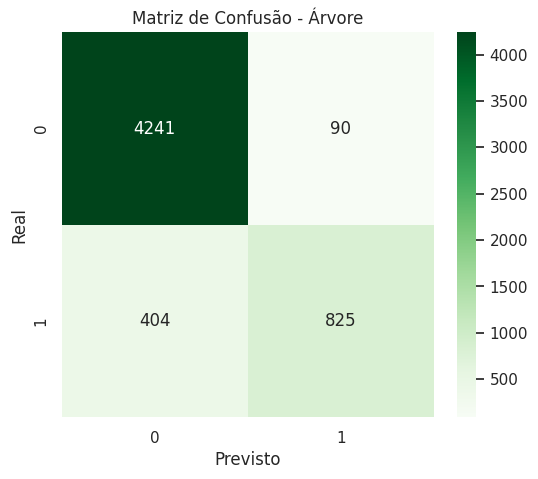

,Modelo,Accuracy,Precision,Recall,F1
0,KNN,0.865288,0.709059,0.662327,0.684897
1,Árvore,0.911151,0.901639,0.671277,0.769590


In [86]:
#Árvore
matriz_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6,5))

sns.heatmap(
    matriz_tree,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Matriz de Confusão - Árvore")

plt.xlabel("Previsto")

plt.ylabel("Real")

plt.show()

comparacao = pd.DataFrame({

    "Modelo":[
        "KNN",
        "Árvore"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_tree)
    ],

    "Precision":[
        precision_score(y_test,y_pred_knn),
        precision_score(y_test,y_pred_tree)
    ],

    "Recall":[
        recall_score(y_test,y_pred_knn),
        recall_score(y_test,y_pred_tree)
    ],

    "F1":[
        f1_score(y_test,y_pred_knn),
        f1_score(y_test,y_pred_tree)
    ]

})

comparacao

Após comparar os modelos KNN e Árvore de Decisão, observou-se que a Árvore apresentou melhor equilíbrio entre precisão, recall e F1-Score, além de menor evidência de overfitting. A análise da matriz de confusão demonstrou uma redução dos falsos negativos, aspecto essencial para o problema de concessão de crédito. Considerando o impacto financeiro da aprovação de empréstimos para clientes inadimplentes, recomenda-se a utilização da Árvore de Decisão em produção, por apresentar melhor capacidade de generalização e maior segurança para a tomada de decisão.

Em aplicações de análise de crédito, o custo associado aos erros de classificação não é equivalente. Enquanto um falso positivo representa a perda de uma oportunidade de negócio ao negar crédito a um bom pagador, o falso negativo resulta na aprovação de crédito para um cliente potencialmente inadimplente, ocasionando prejuízos financeiros. Dessa forma, modelos com maior capacidade de identificar corretamente clientes inadimplentes (maior Recall da classe positiva) tendem a ser mais adequados para esse contexto. No setor financeiro, normalmente o Falso Negativo é o mais crítico, pois representa conceder crédito a um cliente que não pagará o empréstimo, gerando perdas financeiras diretas para a instituição.